# Surface water mass transformation (WMT) of CMIP6 output with `xwmt`

This notebook computes surface water mass transformation (SWMT) from scratch, using only the
standard ocean surface variables that are routinely archived for experiments contributed to the
Coupled Model Intercomparison Project Phase 6 (CMIP6). It reads GFDL-CM4 output directly from the
**public Pangeo CMIP6 archive on Google Cloud Storage**, so anyone can run it — no access to
GFDL's internal filesystem required.

### What you'll learn

- How to load raw CMIP6 output (here GFDL-CM4 `historical`) from the public Pangeo GCS archive,
  resolving the published store version dynamically rather than hardcoding it.
- How to wrap a CMIP6 dataset in an `xgcm.Grid` with the area metric `xwmt` needs.
- How to hand-build an `xbudget` dictionary for the surface heat and salt budgets from 2D surface
  fields alone (`hfds`, `wfo`, `tos`, `sos`) — no interior terms required.
- How to restrict the calculation to a region using the model's `basin` mask.
- How the two binning backends selected by `method=` (`"default"` vs `"xgcm"`) compare.

### Prerequisites

Familiarity with `xarray`, and ideally the basics of `xgcm` (`coords`, `metrics`). Some
background on water mass transformation theory (Walin, 1982) will help in reading the final
figure. `gcsfs` and `zarr` must be installed to read the cloud archive.

**Data: ~330 MB streamed from Google Cloud Storage · needs network access every run · takes
~3 minutes end to end.** Runtime is dominated by cloud streaming rather than computation, and
nothing is cached to disk, so re-running re-downloads the data.

## Import packages

In [1]:
import numpy as np
import xarray as xr
import xgcm
import xwmt
import xbudget

import gcsfs  # provides the gs:// filesystem so xarray can open the Pangeo zarr stores

# Optional (loading to memory and plotting)
from dask.diagnostics import ProgressBar
import matplotlib.pyplot as plt
import os
import warnings

# The gRPC transport underneath gcsfs can log benign `BlockingIOError` tracebacks from
# its asyncio poller thread (a known artifact on macOS). They do not affect the data
# read, so quiet asyncio's exception logger to keep the output below readable.
import logging
logging.getLogger('asyncio').setLevel(logging.CRITICAL)

# Warnings are rendered with only the base name of the file that raised them. The
# default format uses the absolute path, which would bake whoever-ran-this's home
# directory into the committed output and the published documentation -- while
# still showing whether a warning came from a library or from this notebook.
warnings.formatwarning = (
    lambda msg, cat, filename, lineno, *_:
    f"{os.path.basename(filename)}:{lineno}: {cat.__name__}: {msg}\n"
)


## Loading a CMIP6 dataset

This notebook loads GFDL-CM4 output from the public
[Pangeo CMIP6 archive on Google Cloud Storage](https://console.cloud.google.com/storage/browser/cmip6)
(anonymous, read-only access via `gcsfs`), so it can be run by anyone. This is the **same
published ESGF/CMIP6 data** that GFDL also serves locally, so for identical facets and time
period the values are identical.

All relevant variables are loaded into `ds` and the (static) grid fields into a separate list.
The Pangeo zarr stores span the full 1850-2014 historical record; we subset to the **final year
(Jan-Dec 2014)** of the CM4 historical run via `time_slice`. An earlier version of this notebook
used the last five years (`201001-201412`); one year is used here so the notebook can be executed
end to end in a few minutes over the network, and it is sufficient to demonstrate every step. The
stores are chunked one year per chunk along `time`, and the 2014 subset lands exactly on a
stored chunk boundary, so it costs one chunk per variable — the cheapest possible subset. Widen
`time_slice` (e.g.
`slice('2010-01-01', '2014-12-31')`, or `slice(None)` for the entire record) for more years, at
proportionally more download time.

The **domain stays global** — only the time axis is scoped down — so the regional `basin` masking
demonstrated below remains meaningful.

Notes on data availability for these facets on Pangeo:

- `sfdsi` (surface salt flux from sea ice) is not published to the Pangeo archive for GFDL-CM4,
  so it is skipped with a warning. See the note on the salt budget below for what this means
  scientifically.
- The static `basin` and `deptho` fields are only published under the `piControl` experiment on
  Pangeo. Since they are time-invariant model geometry, they are identical to the `historical`
  static fields. The `basin` field (and its `flag_meanings`) is used below to build the regional
  mask.

In [2]:
# Public Pangeo CMIP6 archive on Google Cloud Storage (the same published data
# that GFDL also serves internally), so this runs anywhere with no GFDL access.
activity_id = 'CMIP'
institution_id = 'NOAA-GFDL'
source_id = 'GFDL-CM4'
experiment_id = 'historical'
member_id = 'r1i1p1f1'
table_id = 'Omon'
grid_label = 'gn'
storage_options = {'token': 'anon'}  # anonymous, read-only access

# Subset to the final year (Jan - Dec 2014) of the historical run, which is exactly one
# stored chunk per variable. Set e.g. slice('2010-01-01', '2014-12-31') for five years,
# or slice(None) to use the full 1850-2014 record.
time_slice = slice('2014-01-01', '2014-12-31')

fs = gcsfs.GCSFileSystem(token='anon')

def cmip6_zstore(variable_id, table_id=table_id, experiment_id=experiment_id):
    """Resolve the latest-version public Pangeo GCS zarr store for a CMIP6 dataset.

    Returns a ``gs://`` zarr path. Raises FileNotFoundError if the dataset is not
    published on Pangeo for these facets, rather than guessing a version string.
    """
    prefix = '/'.join([
        'cmip6/CMIP6', activity_id, institution_id, source_id, experiment_id,
        member_id, table_id, variable_id, grid_label,
    ])
    versions = fs.ls(prefix)  # one entry per published version
    return 'gs://' + sorted(versions)[-1] + '/'  # use the latest version

In [3]:
variables = [
    'tos',    # surface temperature
    'sos',    # surface salinity
    'hfds',   # surface heat flux
    'sfdsi',  # sea-ice salt flux (brine rejection) - NOT on Pangeo for GFDL-CM4 (skipped)
    'wfo',    # surface freshwater flux
]

# `chunks={}` reads with each store's own chunking, which for these stores is one
# year per chunk along `time`. Requesting finer chunks here would make dask re-fetch
# the same stored chunk once per timestep; we rechunk to one timestep per chunk
# further below, once the data is in memory.
chunks = {}

ds = xr.Dataset()
for var in variables:
    try:
        store = cmip6_zstore(var)
    except FileNotFoundError:
        warnings.warn(
            f"{var!r} is not published on the public Pangeo CMIP6 archive for "
            f"{source_id}/{experiment_id}; skipping it. (For GFDL-CM4 this omits the "
            f"sea-ice brine-rejection salt flux from the salt budget.)"
        )
        continue
    print('Loading', var)
    da = xr.open_dataset(
        store, engine='zarr', decode_times=True, chunks=chunks,
        backend_kwargs={'storage_options': storage_options},
    )[var]
    ds[var] = da.sel(time=time_slice)

Loading tos


I0728 06:50:34.450842 5332856 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0728 06:50:34.458127 5332872 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(104, generation: 1)
I0728 06:50:34.458255 5332872 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(95, generation: 1)


Loading sos


Loading hfds


3017622997.py:20: UserWarning: 'sfdsi' is not published on the public Pangeo CMIP6 archive for GFDL-CM4/historical; skipping it. (For GFDL-CM4 this omits the sea-ice brine-rejection salt flux from the salt budget.)


Loading wfo


In [4]:
# Stream the year into memory once (~300 MB). Doing this up front means the
# transformation calculations below read from RAM instead of re-fetching from GCS for
# every budget term and every method, which is what otherwise dominates the runtime.
with ProgressBar():
    ds = ds.load()

[                                        ] | 0% Completed | 137.38 us

[                                        ] | 0% Completed | 106.38 ms

[#############                           ] | 33% Completed | 209.49 ms

[#############                           ] | 33% Completed | 313.87 ms

[#############                           ] | 33% Completed | 419.85 ms

...

[##########################              ] | 66% Completed | 1.67 s

[#################################       ] | 83% Completed | 1.78 s

[#################################       ] | 83% Completed | 1.88 s

[####################################    ] | 91% Completed | 1.99 s

[########################################] | 100% Completed | 2.09 s

In [5]:
# Static grid fields. `areacello` is published under `historical`, but `deptho` and
# `basin` are only published under `piControl` on Pangeo (time-invariant model geometry,
# identical across experiments). A missing *required* field raises rather than being
# silently skipped.
grid_ds = []
static_experiment = {'areacello': experiment_id, 'deptho': 'piControl', 'basin': 'piControl'}
required = {'basin', 'areacello'}
for var, expt in static_experiment.items():
    try:
        store = cmip6_zstore(var, table_id='Ofx', experiment_id=expt)
    except FileNotFoundError:
        if var in required:
            raise
        warnings.warn(f"{var!r} not found on Pangeo for {source_id}/{expt}; skipping.")
        continue
    print('Loading', var, '(' + expt + ')')
    grid_ds.append(xr.open_dataset(
        store, engine='zarr', chunks={},
        backend_kwargs={'storage_options': storage_options},
    ).load())

Loading areacello (historical)


Loading deptho (piControl)


Loading basin (piControl)


In [6]:
ds = xr.merge([ds, xr.merge(grid_ds[1:], compat="override")], compat="override")

# Area needs to be loaded seperately after renaming MOM6-specific dimension names (xh, yh)
ds['areacello'] = grid_ds[0].areacello.rename({'xh': 'x', 'yh': 'y'})

In [7]:
# Add core coordinates of ocean_grid to ds
ds = ds.assign_coords({
    "areacello": xr.DataArray(ds["areacello"].values, dims=('y', 'x',)), # Required for area-integration
    "lon":       xr.DataArray(ds["lon"].values, dims=('y', 'x',)), # Required for calculating density if not already provided!
    "lat":       xr.DataArray(ds["lat"].values, dims=('y', 'x',)), # Required for calculating density if not already provided!
})

# One timestep per chunk keeps each dask task small during the transformation below.
ds = ds.chunk({'time': 1, 'x': -1, 'y': -1})

# xgcm grid for dataset
coords = {
    'X': {'center': 'x',},
    'Y': {'center': 'y',},
}
metrics = {
    ('X','Y'): "areacello", # Required for area-integration
}
grid = xgcm.Grid(ds, coords=coords, metrics=metrics, padding={"X":"periodic", "Y":"extend"}, autoparse_metadata=False)

## Example plot of surface temperature

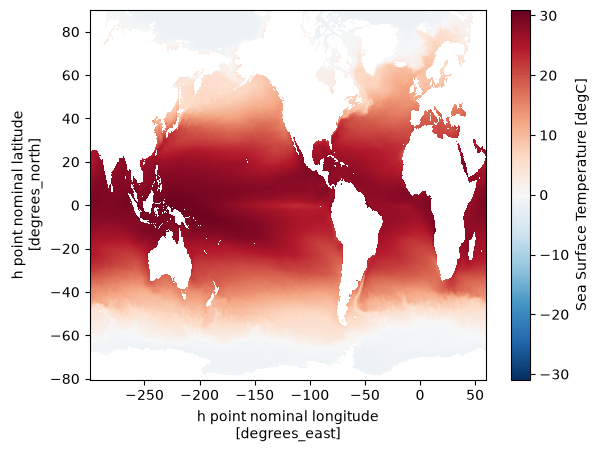

In [8]:
ds['tos'].mean('time').plot();

## Specify mask to apply for SWMT calculation

The static `basin` field carries a `flag_meanings` attribute naming each basin, which we use to
build a regional mask. Because the full global domain was loaded, any of the basins listed below
can be selected; here we use the tropical Pacific.

In [9]:
basin_name = 'pacific_tropc' # global, atlantic, indian, pacific, southern, arctic,
# atlantic_subpN,  pacific_tropc

bidx = [item.split('_')[0] for item in ds.basin.flag_meanings.split(' ')].index(basin_name.split('_')[0])

if basin_name=='global':
    mask = xr.where(ds.basin==bidx,0,1)
else:
    mask = ds.basin==bidx

In [10]:
if basin_name[-6:]=='_tropc':
    mask = mask & (ds["lat"]<=20) & (ds["lat"]>=-20)
if basin_name[-6:]=='_subtN':
    mask = mask & (ds["lat"]<=45) & (ds["lat"]>20)
if basin_name[-6:]=='_subpN':
    mask = mask & (ds["lat"]>45)
if basin_name[-6:]=='_subtS':
    mask = mask & (ds["lat"]>=-45) & (ds["lat"]<-20)

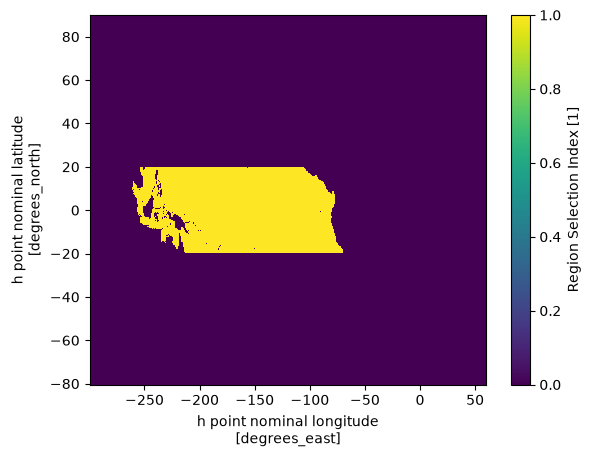

In [11]:
mask.plot();

## Construct xbudget dictionary

### A note on the salt budget: no brine rejection

`xwmt` would normally account for the salt flux associated with sea-ice formation and melt
(brine rejection) through the `sfdsi` field. GFDL-CM4 does not publish `sfdsi` to the Pangeo
archive, so the loader above warned and skipped it, and the salt budget assembled below
contains only the freshwater-flux (`wfo`) terms.

This is a *scientific* limitation, not merely a missing log line. The salt budget here is
incomplete wherever sea ice forms or melts, so transformation rates in the sea-ice zones — the
Southern Ocean and the Arctic in particular — are **biased**: the dense water formation driven by
brine rejection is simply absent from the calculation. The tropical Pacific region selected above
is ice-free year round, so the result shown here is unaffected by the omission. If you change
`basin_name` to a high-latitude basin, interpret the salinity-driven transformation with that
caveat firmly in mind. To include brine rejection, obtain `sfdsi` from ESGF or a local CMIP6
mirror and add a `surface_exchange_flux_nonadvective` term to the salt budget below, mirroring
the `hfds` term in the heat budget.

In [12]:
budgets_dict = {
    "mass": {},
    "heat": {"surface_lambda": "tos"},
    "salt": {"surface_lambda": "sos"}
}

In [13]:
cp = 3992.
rho_ref = 1035.
budgets_dict['heat']['rhs'] = {
    'var': None,
    'sum': {
        'var': None,
        'surface_exchange_flux_nonadvective': {
            'var': None,
            'product': {
                'var': None,
                'heat_tendency':'hfds',
                'area':'areacello'
            }
        },
        'surface_exchange_flux_advective': {
            'var': None,
            'product': {
                'var': None,
                'specific_heat_capacity': cp,
                'lambda_mass': 'tos',
                'mass_density_tendency': 'wfo',
                'area': 'areacello'
            }
        },
        'surface_ocean_flux_advective': {
            'var': None,
            'product': {
                'var': None,
                'sign': -1.,
                'specific_heat_capacity': cp,
                'lambda_mass': 'tos',
                'mass_density_tendency': 'wfo',
                'area': 'areacello'
            }
        }
    }
}
budgets_dict['salt']['rhs'] = {
    'var': None,
    'sum': {
        'var': None,
        'surface_exchange_flux_advective': {
            'var': None,
            'product': {
                'var': None,
                'unit_conversion': 0.001,
                'lambda_mass': 0.,
                'mass_density_tendency': 'wfo',
                'area': 'areacello'
            }
        },
        'surface_ocean_flux_advective': {
            'var': None,
            'product': {
                'var': None,
                'sign': -1.,
                'unit_conversion': 0.001,
                'lambda_mass': 'sos',
                'mass_density_tendency': 'wfo',
                'area': 'areacello'
            }
        }
    }
}

## Reconstruct budget terms using the 2D fields
xbudget.collect_budgets(grid._ds, budgets_dict)
simple_budget = xbudget.BudgetQuery(grid._ds, budgets_dict).aggregate() # aggregate to the root level

## Compute and visualize transformations

`xwmt` provides two backends for binning transformations onto the density coordinate, selected
with the `method=` keyword:

- `method="default"` uses `xhistogram` for the area-integrated WMT calculation (and `xgcm` for
  spatial transformation maps).
- `method="xgcm"` uses `xgcm.transform` throughout.

The two are equivalent up to binning details, so the two panels below should agree closely; they
differ in performance and in which downstream operations are supported. Comparing them on the
same data is a useful sanity check when adopting either.

We use density bins of 0.2 kg m$^{-3}$ (`np.arange(10, 30, 0.2)`), coarser than the 0.1 spacing
used previously, which halves the binning work while still resolving the structure of the
transformation.

Method: default
[                                        ] | 0% Completed | 137.17 us

[##############                          ] | 35% Completed | 106.95 ms

[##########################              ] | 67% Completed | 210.66 ms

[###################################     ] | 88% Completed | 312.33 ms

[########################################] | 100% Completed | 419.11 ms

...

[#####################################   ] | 94% Completed | 32.37 s

[#####################################   ] | 94% Completed | 32.48 s

[######################################  ] | 95% Completed | 32.61 s

[######################################  ] | 96% Completed | 32.83 s

[########################################] | 100% Completed | 32.93 s

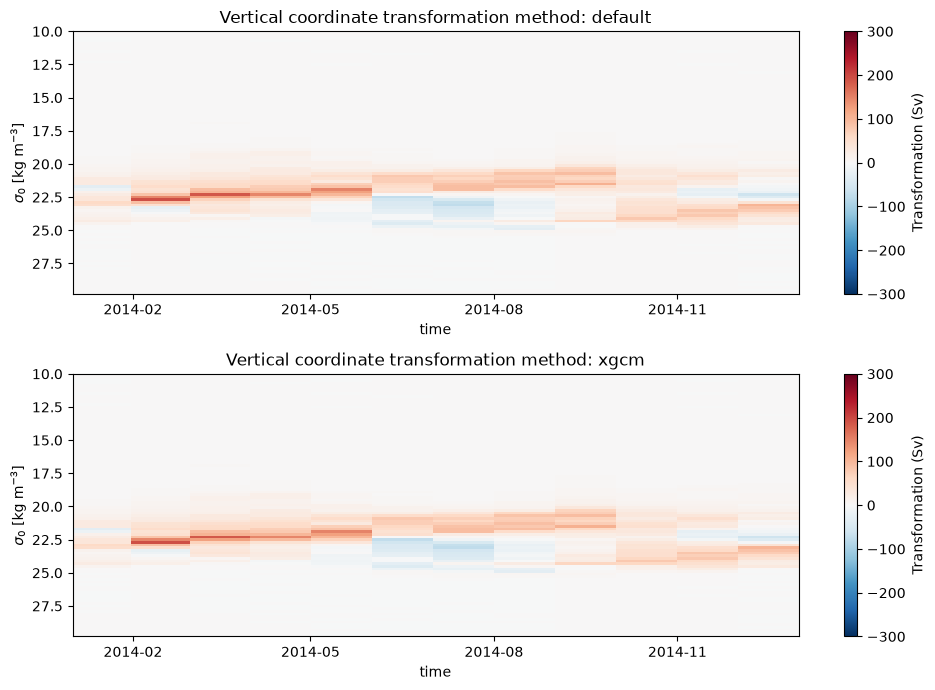

In [14]:
plt.figure(figsize=(10,7))
for i, method in enumerate(["default", "xgcm"]):
    print(f"Method: {method}")
    # xwmt's internal `xr.merge` of the budget terms triggers an xarray FutureWarning
    # about upcoming changes to the default join/compat behaviour. It is raised inside
    # xwmt and is not actionable from this notebook, so we silence it here to keep the
    # output readable.
    with warnings.catch_warnings():
        warnings.simplefilter(action='ignore', category=FutureWarning)
        swmt = xwmt.WaterMassTransformations(grid, simple_budget, mask=mask, cp=cp, rho_ref=rho_ref, method=method)
        G = swmt.integrate_transformations("sigma0", bins=np.arange(10, 30, 0.2))
        with ProgressBar():
            G['surface_exchange_flux_nonadvective'].load()
            G['surface_exchange_flux_advective'].load()
            G['surface_ocean_flux_advective'].load()

        ax = plt.subplot(2,1,i+1)
        ((G['surface_exchange_flux_nonadvective'] +
         G['surface_exchange_flux_advective'] +
         G['surface_ocean_flux_advective']
        )/rho_ref*1.e-6).T.plot(
            ax=ax,cmap='RdBu_r',vmin=-300,vmax=300,yincrease=False,
            cbar_kwargs={'label': 'Transformation (Sv)'}
        );
    plt.title(f"Vertical coordinate transformation method: {method}")
    # Label the density axis explicitly. The two backends disagree on what to put
    # there by default: xhistogram copies the source variable's attributes onto the
    # target bin coordinate, while xgcm.transform does not, so one panel would be
    # labelled from `long_name` and the other with the bare coordinate name.
    ax.set_ylabel(r"$\sigma_{0}$ [kg m$^{-3}$]")
plt.tight_layout()